<a href="https://colab.research.google.com/github/Davron030901/Machine_Learning/blob/main/4_optimizer_showdown.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏔️ How a Neural Network LEARNS
## The Optimizer Showdown (NLP edition) 🥊

Hi! 👋 Today we watch a brain go from **dumb** to **smart**. 🧠
It starts with random weights and guesses garbage. 🗑️
Then it repeats a tiny 4-step loop MANY times... and learns! 🔁

The 4 steps: 🪜
1. 🤔 **Guess**
2. 😬 **Measure the "Oops" score** (loss)
3. 🧭 **Find the fix** (which way is downhill)
4. 👣 **Take a step** (update the weights)

Run each box with **Shift + Enter**. Let's go! 🚀

## Step 1: Get our tools 🛠️
Just NumPy (numbers) and Matplotlib (drawing curves). 🔢📈

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("Tools ready! 🎉")

Tools ready! 🎉


## Step 2: Our toy NLP data 📒

Same words as always: **i, love, hate, pizza, you** 🍕
Each sentence becomes 5 numbers (1 = word is here, 0 = not).
Answer: happy = 1 😄, sad = 0 😢

We made a few copies so the brain has enough to practice on. 💪

In [2]:
# vocab order: i, love, hate, pizza, you
# Each row = a sentence as a vector. Each y = the right answer.
base_X = np.array([
    [1,1,0,1,0],  # i love pizza -> happy
    [1,0,1,1,0],  # i hate pizza -> sad
    [1,1,0,0,1],  # i love you   -> happy
    [1,0,1,0,1],  # i hate you   -> sad
    [0,1,0,1,0],  # love pizza   -> happy
    [0,0,1,1,0],  # hate pizza   -> sad
    [0,1,0,0,1],  # love you     -> happy
    [0,0,1,0,1],  # hate you     -> sad
], dtype="float32")
base_y = np.array([1,0,1,0,1,0,1,0], dtype="float32")

# stack a few copies so curves look smooth (more practice rounds)
X = np.vstack([base_X]*8)
y = np.concatenate([base_y]*8)
print("We have", len(X), "training sentences. 📚")
print("First sentence:", X[0], "-> answer", y[0], "😄")

We have 64 training sentences. 📚
First sentence: [1. 1. 0. 1. 0.] -> answer 1.0 😄


## Step 3: A tiny brain 🧠

Our brain is simple:
- Take the 5 word-numbers
- Multiply by **weights** (importance points) ⭐
- Add them up ➕
- Squish with **sigmoid** into a 0–1 "yes meter" 🎚️

If the meter is near 1 → happy 😄. Near 0 → sad 😢.

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def guess(weights, bias, X):
    score = X @ weights + bias    # multiply + add up ➕
    return sigmoid(score)         # squish to 0..1 🎚️

# The "Oops" score (loss): how wrong are we, on average? 😬
def oops_score(pred, y):
    return np.mean((pred - y) ** 2)   # squared gap

print("Brain ready! 🧠")

Brain ready! 🧠


## Step 3.5: 🧱 What does ONE neuron do? (slow!)

Before training, let's see ONE neuron think. It does 3 tiny jobs:
1. ✖️ **Multiply** each word by its weight
2. ➕ **Add** them all up (this sum is called `z`)
3. 🚪 **Squish** with sigmoid → the guess

Let's do "i love pizza" = `[1, 1, 0, 1, 0]` by hand, with these weights:
i=0.0, love=0.5, hate=−0.5, pizza=0.2, you=0.0 ⭐

In [4]:
# one sentence, one set of weights
x_one = np.array([1, 1, 0, 1, 0], dtype="float32")
w_demo = np.array([0.0, 0.5, -0.5, 0.2, 0.0], dtype="float32")
b_demo = 0.0

# Step 1+2: multiply and add up ➕
z = np.sum(x_one * w_demo) + b_demo
print("Each word x its weight:", x_one * w_demo)
print("Add them up -> z =", round(z, 3))

# Step 3: squish 🚪
g = sigmoid(z)
print("guess = sigmoid(z) =", round(g, 3), "😄")
print()
print("So the brain is 0.67 sure this is HAPPY!")

Each word x its weight: [ 0.   0.5 -0.   0.2  0. ]
Add them up -> z = 0.7
guess = sigmoid(z) = 0.668 😄

So the brain is 0.67 sure this is HAPPY!


### 👀 What just happened?
- `z = 0 + 0.5 + 0 + 0.2 + 0 = 0.7`
- `sigmoid(0.7) = 0.67`
- Words NOT in the sentence (hate, you) had input 0, so they added nothing. 😴

That is ALL a neuron does: multiply, add, squish. 🧱

## Step 3.6: ⭐ ONE FULL LOOP, by hand (the big one!)

Now the important part. Let's run ALL 4 steps for "i love pizza".
The right answer is **happy = 1**. 😄
Watch the loss SHRINK! 📉

In [5]:
y_one = 1.0           # the right answer (happy)
lr = 0.5              # learning rate (step size) 👣

# ① GUESS 🤔
g = sigmoid(np.sum(x_one * w_demo) + b_demo)
print("① guess        =", round(g, 3))

# ② MEASURE the oops 😬
error = g - y_one
loss  = error ** 2
print("② error        =", round(error, 3), "(negative = guessed too low)")
print("   loss (oops)  =", round(loss, 3))

# ③ FIND THE FIX (blame) 🧭  -> blame = error x input
blame = error * x_one
print("③ blame each   =", np.round(blame, 3), "(hate & you = 0, not in sentence!)")

# ④ STEP: nudge the weights 👣  -> new = old - lr x blame
w_new = w_demo - lr * blame
print("④ new weights  =", np.round(w_new, 3))

# Now guess AGAIN with the new weights 🎉
g2 = sigmoid(np.sum(x_one * w_new) + b_demo)
loss2 = (g2 - y_one) ** 2
print()
print("New guess =", round(g2, 3), " (was", round(g, 3), ")  moved toward 1! 📈")
print("New loss  =", round(loss2, 3), " (was", round(loss, 3), ")  smaller! 📉")
print("🎉 The brain LEARNED in one step!")

① guess        = 0.668
② error        = -0.332 (negative = guessed too low)
   loss (oops)  = 0.11
③ blame each   = [-0.332 -0.332 -0.    -0.332 -0.   ] (hate & you = 0, not in sentence!)
④ new weights  = [ 0.166  0.666 -0.5    0.366  0.   ]

New guess = 0.768  (was 0.668 )  moved toward 1! 📈
New loss  = 0.054  (was 0.11 )  smaller! 📉
🎉 The brain LEARNED in one step!


### 🔑 The whole secret
Loss dropped **0.11 → 0.05**. The guess moved **0.67 → 0.77** (toward happy). 🎉

Training just repeats this loop for every sentence, thousands of times.
Each tiny nudge shrinks the loss a little more. That's it! 💪

Now let's automate the loop and race the optimizers. 👇

## Step 4: The 4-step loop, by hand 🔁

Watch the math! With tiny numbers. 🔢

1. 🤔 Guess with current weights
2. 😬 Measure the oops score
3. 🧭 Find the fix (the "gradient" = which way is downhill ⛰️)
4. 👣 Step: `weight = weight − learning_rate × fix`

The minus means "walk DOWNHILL toward less oops." ⬇️

In [6]:
# This function trains the brain and remembers the oops score each round.
def train(optimizer="sgd", learning_rate=0.5, rounds=60, seed=1):
    rng = np.random.RandomState(seed)
    weights = rng.randn(5) * 0.1   # 🎲 random start (dumb!)
    bias = 0.0

    # extra "memory" boxes that smart optimizers use:
    velocity = np.zeros(5)         # for Momentum (a rolling ball ⚽)
    v_bias = 0.0
    cache = np.zeros(5)            # for Adam (smart brakes 🛑)
    c_bias = 0.0

    history = []
    for r in range(rounds):
        # 1+2: guess and measure 🤔😬
        pred = guess(weights, bias, X)
        history.append(oops_score(pred, y))

        # 3: find the fix (gradient) 🧭
        error = pred - y
        grad_w = (X.T @ error) / len(X)
        grad_b = np.mean(error)

        # 4: take a step 👣 — different optimizers step differently!
        if optimizer == "sgd":
            weights -= learning_rate * grad_w
            bias    -= learning_rate * grad_b

        elif optimizer == "momentum":
            velocity = 0.9 * velocity + grad_w   # ⚽ build speed
            v_bias   = 0.9 * v_bias   + grad_b
            weights -= learning_rate * velocity
            bias    -= learning_rate * v_bias

        elif optimizer == "adam":
            cache = 0.9 * cache + 0.1 * (grad_w ** 2)   # 🛑 smart brakes
            c_bias = 0.9 * c_bias + 0.1 * (grad_b ** 2)
            weights -= learning_rate * grad_w / (np.sqrt(cache) + 1e-8)
            bias    -= learning_rate * grad_b / (np.sqrt(c_bias) + 1e-8)

    return history, weights, bias

# Try one run! 🏃
hist, w, b = train("sgd", learning_rate=0.5, rounds=60)
print("Start oops:", round(hist[0], 3), "😬 (bad!)")
print("End oops:  ", round(hist[-1], 3), "🎉 (better!)")

Start oops: 0.252 😬 (bad!)
End oops:   0.005 🎉 (better!)


## Step 5: 🥊 THE OPTIMIZER SHOWDOWN

Now the fun part! 🎉
Three different "walking styles" race down the oops mountain. 🏔️

- 🐢 **SGD** = plain steps downhill
- ⚽ **Momentum** = a rolling ball, builds speed
- 🧭 **Adam** = momentum + smart brakes (the usual default!)

Watch which one drops the oops score fastest! 📉

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


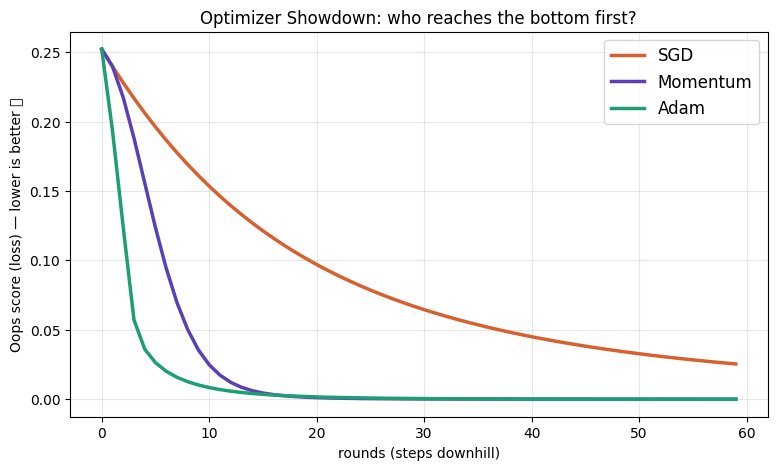

The lower the line, the smarter the brain! 🧠


In [7]:
plt.figure(figsize=(9, 5))
for name, label, color in [("sgd","SGD","#D8602F"),
                           ("momentum","Momentum","#5B3FB5"),
                           ("adam","Adam","#1D9E75")]:
    hist, _, _ = train(name, learning_rate=0.2, rounds=60)
    plt.plot(hist, label=label, color=color, linewidth=2.5)

plt.title("Optimizer Showdown: who reaches the bottom first?")
plt.xlabel("rounds (steps downhill)")
plt.ylabel("Oops score (loss) — lower is better 📉")
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()
print("The lower the line, the smarter the brain! 🧠")

### 👀 What you should see
- All three lines go **DOWN** (they all learn). 📉
- **Adam** 🧭 usually dives down fastest and smoothest.
- **SGD** 🐢 is slower.

That's why people say: "just start with Adam." ✅

## Step 6: 👣 The Learning Rate game (the valley!) 🏔️

The learning rate = **how big each step is**.

Let's use the simplest picture: a ball in a **valley**. 🥣
The bottom of the valley = 0 oops (perfect!). 🎯
The ball starts high up at **5**. Each step it rolls toward 0.

Math: the slope at point `w` is `2 × w`.
Step: `w = w − learning_rate × (2 × w)` 👣

Let's test 3 step sizes! 🎮

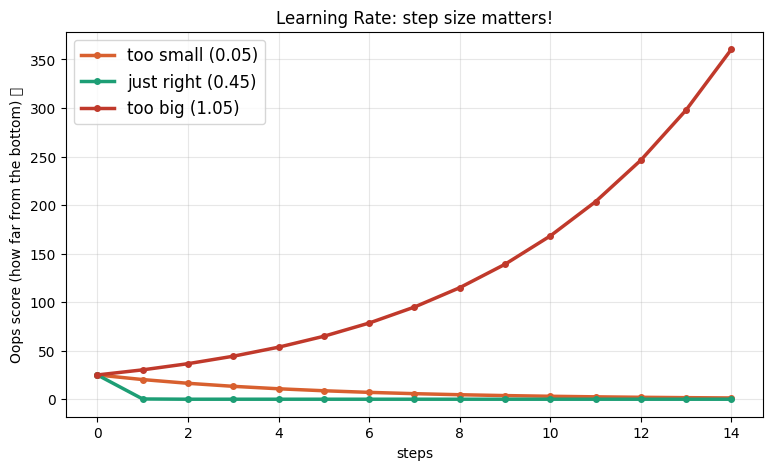

Where the ball lands each step (goal = 0):
  too small 🐌: +5.00, +4.50, +4.05, +3.64, +3.28, +2.95, +2.66
  just right 🎯: +5.00, +0.50, +0.05, +0.00, +0.00, +0.00, +0.00
  too big 🦘: +5.00, -5.50, +6.05, -6.66, +7.32, -8.05, +8.86


In [8]:
def valley(lr, steps=14, start=5.0):
    w = start
    path = [w]
    for _ in range(steps):
        slope = 2 * w              # which way is downhill ⛰️
        w = w - lr * slope         # take a step 👣
        path.append(w)
    return path

plt.figure(figsize=(9, 5))
for lr, label, color in [(0.05,"too small (0.05)","#D8602F"),
                         (0.45,"just right (0.45)","#1D9E75"),
                         (1.05,"too big (1.05)","#C0392B")]:
    path = valley(lr)
    loss = [w*w for w in path]     # oops score = w squared
    plt.plot(loss, label=label, color=color, linewidth=2.5, marker="o", markersize=4)

plt.title("Learning Rate: step size matters!")
plt.xlabel("steps")
plt.ylabel("Oops score (how far from the bottom) 📉")
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

# Show the numbers too! 🔢
print("Where the ball lands each step (goal = 0):")
for lr, name in [(0.05,"too small 🐌"), (0.45,"just right 🎯"), (1.05,"too big 🦘")]:
    p = valley(lr, steps=6)
    print(f"  {name}: " + ", ".join(f"{x:+.2f}" for x in p))

### 👀 What you should see
- 🐌 **too small**: the ball crawls down. So slow! 😴
- 🎯 **just right**: the ball drops to the bottom fast.
- 🦘 **too big**: the ball OVERSHOOTS and bounces — it gets WORSE and flies away! 💥

The numbers for "too big" go: +5 → −5.5 → +6 → −6.6 ... bigger and bigger! 😱

### 🔑 The big lesson
The learning rate is the **#1 knob** people tune. 🎛️
- 🐌 Too small = slow and boring.
- 🦘 Too big = breaks everything (the ball flies out of the valley!).
- 🎯 Just right = smooth, fast learning.

## Step 7: 🎓 Your turn! (mini homework)

Try these — just change the numbers and re-run: ✏️
1. In Step 5, change `rounds=60` to `rounds=150`. Does Adam still win? 🤔
2. In Step 6, try a learning rate of `1.0` in the valley. Does the ball settle or bounce? 👣
3. In Step 6, try `0.5` — is it just right, or does it bounce a little? 🥣

Write 2 sentences about what you saw. 📝

🏆 You just watched a brain LEARN — guess, measure, fix, step, repeat! 🔁

## 📖 Mini Glossary

| Word | Simple meaning |
|------|----------------|
| Weight ⭐ | How much a word pushes toward happy/sad |
| z (the sum) | All inputs × weights, added up |
| Sigmoid 🚪 | The gate that squishes z into a 0–1 guess |
| Loss / Oops 😬 | The "how wrong am I" number |
| Gradient / blame 🧭 | Which way (and how much) to nudge a weight |
| Backprop 🔙 | Finding the blame for every weight |
| Learning rate 👣 | How big each step is |
| Optimizer 🚶 | The rule for how to step (SGD, Momentum, Adam) |
| Epoch 🔄 | One full pass through all the data |
| Batch 📦 | A small handful of examples |
| Iteration 🔁 | One weight update (one batch) |
